In [173]:
#libraries and dirrectory 
import pandas as pd
import numpy as np
import os
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score
from scipy.optimize import curve_fit
import patientFunctions as ptfn
import seaborn as sns
import matplotlib.pyplot as plt
import re
import matplotlib.patches as mpatches
from collections import Counter



#directory

# machine_directory = 'C:/Users/mcremer' #the C and path to the project folder
machine_directory = 'C:/Users/maega' #when working from home machine
storage_directory = 'UFL Dropbox/Maegan Cremer/research-share/Maegan/Projects' #Local, HPG, or dropbox
project_directory = 'Cardiac-Amyloidosis-Multiple-Myeloma' #project folder
project_lv2_directory = '019_Mistic_ClinicalSplit' #deeper part of project folder

path = os.path.join(machine_directory, storage_directory, 
                    project_directory, project_lv2_directory)

# parent_dir = path
outputDir = path
os.chdir(outputDir)

In [174]:
#outputs
folderNameHeader = "FeatListCompare_"
folderNameCommon = ""
folderNameSuffix = "_2025-07"

# fileNameHeader_1 = "DF_SelectedFeats_"
# # fileNameHeader_2 = "ALUnknownPts"
# # fileNameCommon = "_Features"
fileNameSuffix = "_2025-07"

folder_data_out = ptfn.makeFolderPathForData(parent_dir=outputDir, folderName_header=folderNameHeader, 
                                        folderName_common=folderNameCommon, folderName_suffix=folderNameSuffix)


folderNameOut = folder_data_out

In [175]:
#model dictionary construction
modelNames = ['EchoAdj', 'DescOnly', 'ParamsOnly', 'DescFits']
modelNames_dict = {'EchoAdj': 'EchoAdj',
                   'DescOnly': 'DescOnly',
                   'ParamsOnly': 'ParamsOnly',
                   'DescFits': 'DescFits'}

# first round feature selection

In [ ]:
#import files for list of features
selectedFeaturesFolder = os.path.join(outputDir, "DF_SelectedFeats_20250523" )

#directory for where selected features are stored
FilesInFolder = os.listdir(selectedFeaturesFolder)


#dictionary of selected features
dict_selected_feats = {}

dict_feats_origData = {} #original data section of the feature
dict_feats_transforms = {} #for the transformations applied to the original data

dict_dataimport_all = {}
dict_dataimport_positive={}
dict_dataimport_negative = {}

#import each file in that directory to a pandas object 
for model in modelNames: 
    for fileName in FilesInFolder:
        if model in fileName:
            #import the data as pandas
            featuresData = pd.read_excel(os.path.join(selectedFeaturesFolder, fileName), sheet_name = 'all')
            dict_dataimport_all[model] = featuresData
            #get only the header row
            featuresList = featuresData.columns[1:]
            #add the features list to dictionary with the model as the key
            dict_selected_feats[model] = featuresList

            #parsing the featurs into the first and second part
            ogData_temp = [feature.split('_')[0] for feature in featuresList]
            transforms_temp = [" ".join(feature.split('_')[1:]) for feature in featuresList]

            dict_feats_origData[model] = ogData_temp
            dict_feats_transforms[model] = transforms_temp

            featuresDataPositive = pd.read_excel(os.path.join(selectedFeaturesFolder, fileName), sheet_name = 'positive')
            dict_dataimport_positive[model] = featuresDataPositive
            featuresDataNegative = pd.read_excel(os.path.join(selectedFeaturesFolder, fileName), sheet_name = 'negative')
            dict_dataimport_negative[model] = featuresDataNegative


In [201]:
#get count information for features, original data, and tranformations
i = 0
for model in modelNames:
    # selected_feats = dict_selected_feats[model]
    count_selectedFeats_model = pd.DataFrame.from_dict(Counter(dict_selected_feats[model]), orient = 'index')
    count_orgData_model = pd.DataFrame.from_dict(Counter(dict_feats_origData[model]), orient = 'index')
    count_transforms_model = pd.DataFrame.from_dict(Counter(dict_feats_transforms[model]), orient = 'index')
    if i == 0: 
        count_selectedFeats = count_selectedFeats_model
        count_orgData= count_orgData_model
        count_transforms = count_transforms_model
    else: 
        count_selectedFeats= pd.concat([count_selectedFeats, count_selectedFeats_model], axis= 1)
        count_orgData = pd.concat([count_orgData, count_orgData_model], axis= 1)
        count_transforms = pd.concat([count_transforms, count_transforms_model], axis = 1)
    i = i+1

count_selectedFeats.columns = modelNames
count_orgData.columns = modelNames
count_transforms.columns = modelNames


# second round feature selection

In [205]:
#import files for list of features
selectedFeaturesFolder = os.path.join(outputDir, "DF_SelectedFeats_Second_202507" )

#directory for where selected features are stored
FilesInFolder = os.listdir(selectedFeaturesFolder)


#dictionary of selected features
dict_selected_feats_second = {}

dict_feats_second_origData = {} #original data section of the feature
dict_feats_second_transforms = {} #for the transformations applied to the original data

#saving imported data
dict_dataimport_all_second = {}

dict_dataimport_positive_second={}
dict_dataimport_negative_second = {}


#import each file in that directory to a pandas object 
for model in modelNames: 
    for fileName in FilesInFolder:
        if model in fileName:
            #import the data as pandas
            featuresData = pd.read_excel(os.path.join(selectedFeaturesFolder, fileName), sheet_name = 'all')
            dict_dataimport_all_second[model] = featuresData
            #get only the header row
            featuresList = featuresData.columns[1:]
            #add the features list to dictionary with the model as the key
            dict_selected_feats_second[model] = featuresList

            #parsing the featurs into the first and second part
            ogData_temp = [feature.split('_')[0] for feature in featuresList]
            transforms_temp = [" ".join(feature.split('_')[1:]) for feature in featuresList]

            dict_feats_second_origData[model] = ogData_temp
            dict_feats_second_transforms[model] = transforms_temp

            featuresDataPositive = pd.read_excel(os.path.join(selectedFeaturesFolder, fileName), sheet_name = 'positive')
            dict_dataimport_positive_second[model] = featuresDataPositive
            featuresDataNegative = pd.read_excel(os.path.join(selectedFeaturesFolder, fileName), sheet_name = 'negative')
            dict_dataimport_negative_second[model] = featuresDataNegative




In [182]:
#get count information for features, original data, and tranformations
i = 0
for model in modelNames:
    count_selectedFeats_model = pd.DataFrame.from_dict(Counter(dict_selected_feats_second[model]), orient = 'index')
    count_orgData_model = pd.DataFrame.from_dict(Counter(dict_feats_second_origData[model]), orient = 'index')
    count_transforms_model = pd.DataFrame.from_dict(Counter(dict_feats_second_transforms[model]), orient = 'index')
    if i == 0: 
        count_selectedFeats_second = count_selectedFeats_model
        count_orgData_second = count_orgData_model
        count_transforms_second = count_transforms_model
    else: 
        count_selectedFeats_second= pd.concat([count_selectedFeats_second, count_selectedFeats_model], axis= 1)
        count_orgData_second = pd.concat([count_orgData_second, count_orgData_model], axis= 1)
        count_transforms_second = pd.concat([count_transforms_second, count_transforms_model], axis = 1)
    i = i+1

count_selectedFeats_second.columns = modelNames
count_orgData_second.columns = modelNames
count_transforms_second.columns = modelNames


# frequency of original data

In [183]:
#import file for frequency of original data

# visualization first round feature selection

## frequency of features

In [184]:
#heatmap for original data across models
cmap = 'magma_r'

<Axes: >

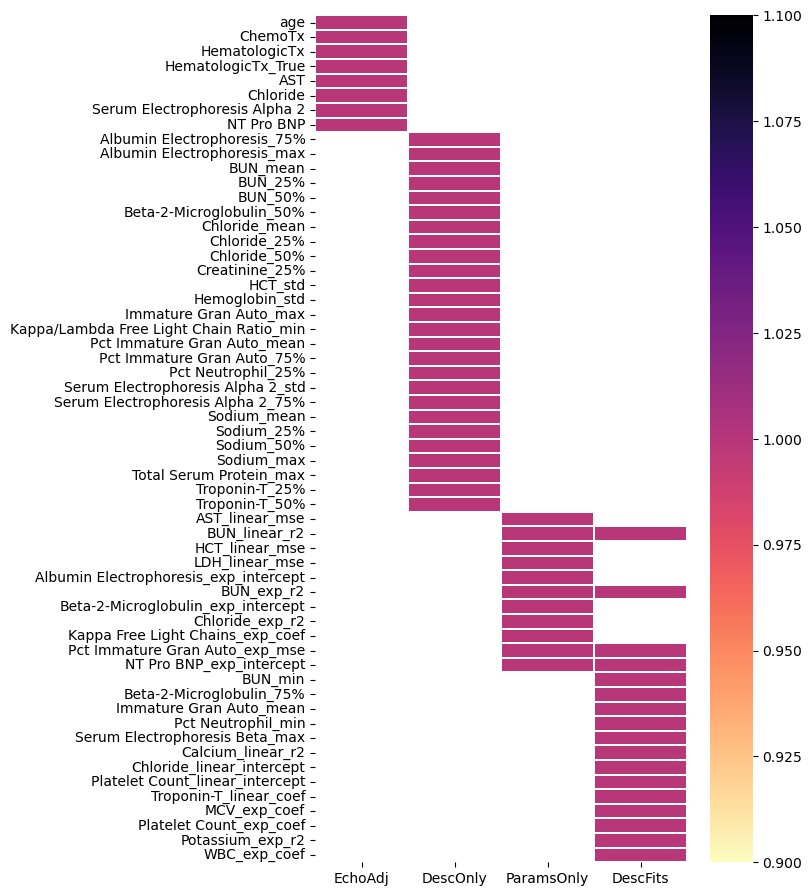

In [185]:
#plotting heatmap for feature frequency across models
fig, ax = plt.subplots(figsize = (6,11))
sns.heatmap(count_selectedFeats, cmap = cmap, ax = ax, linewidths=0.1)

Text(0.5, 1.0, 'Frequency of Data Characteristic')

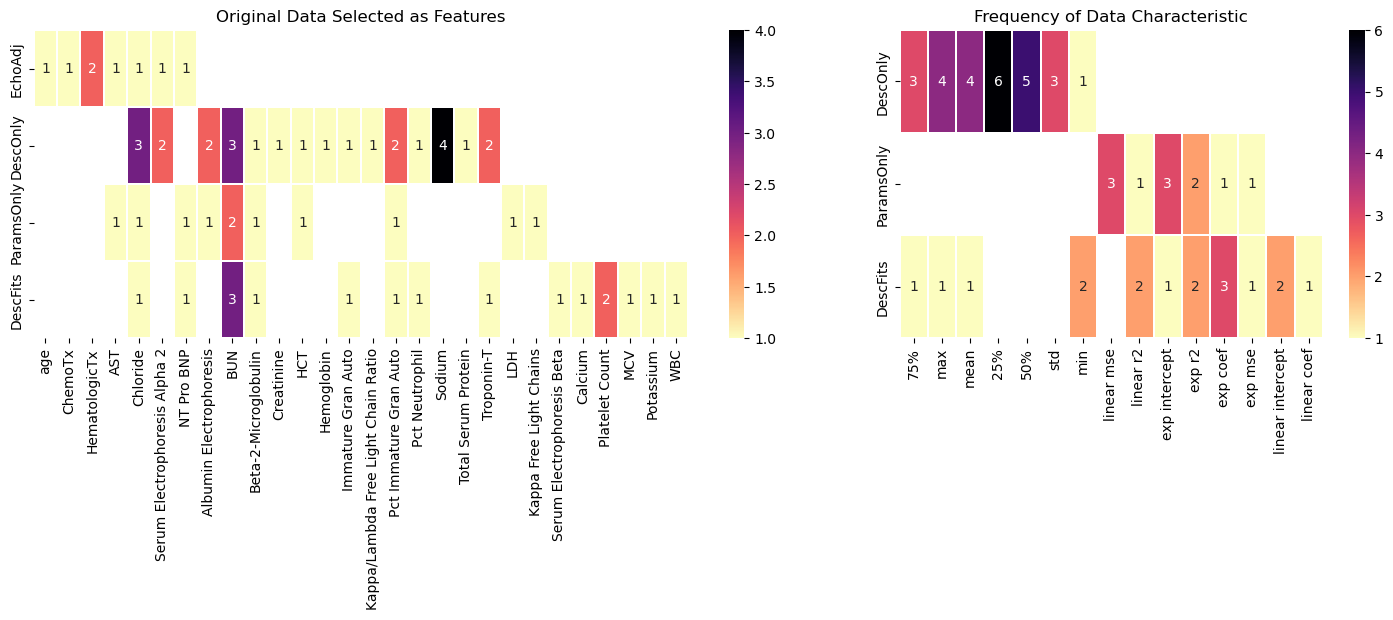

In [222]:
#heatmap for orignial data and transformation frequency across models
fig= plt.figure(figsize = (18,4))
ax1 = plt.subplot2grid((1, 5), (0,0), colspan = 3)
sns.heatmap(count_orgData.T, ax=ax1, cmap = cmap, linewidths=0.1, annot= True)
ax1.set_title("Original Data Selected as Features")
ax2 = plt.subplot2grid((1, 5), (0,3), colspan=2)
sns.heatmap(count_transforms.iloc[2:].T.iloc[1:], ax=ax2, cmap = cmap, linewidths=0.1, annot = True)
ax2.set_title("Frequency of Data Characteristic")

<Axes: >

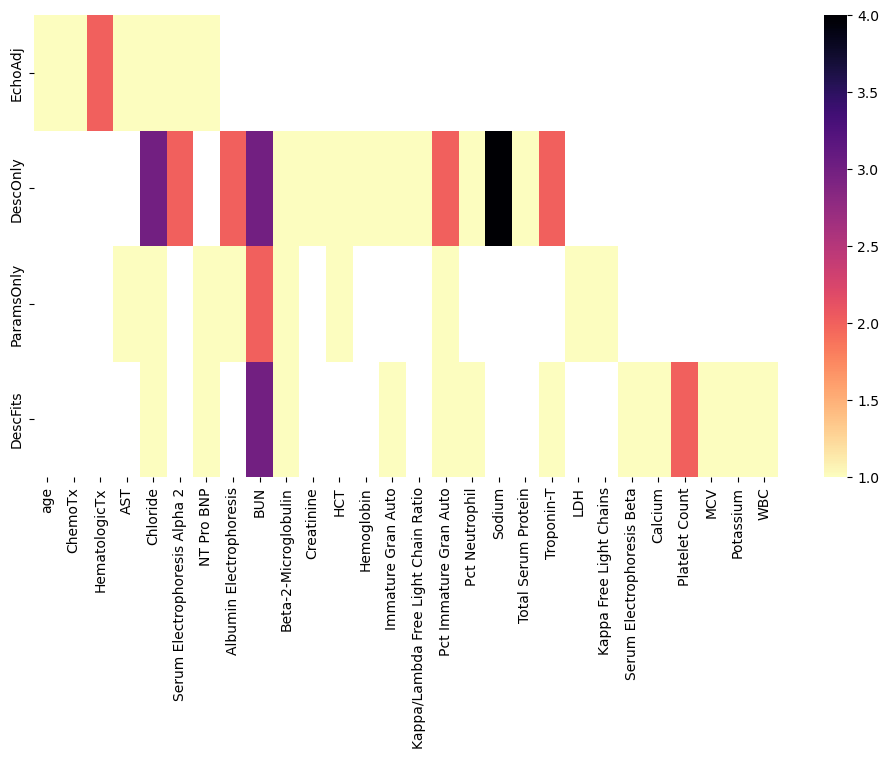

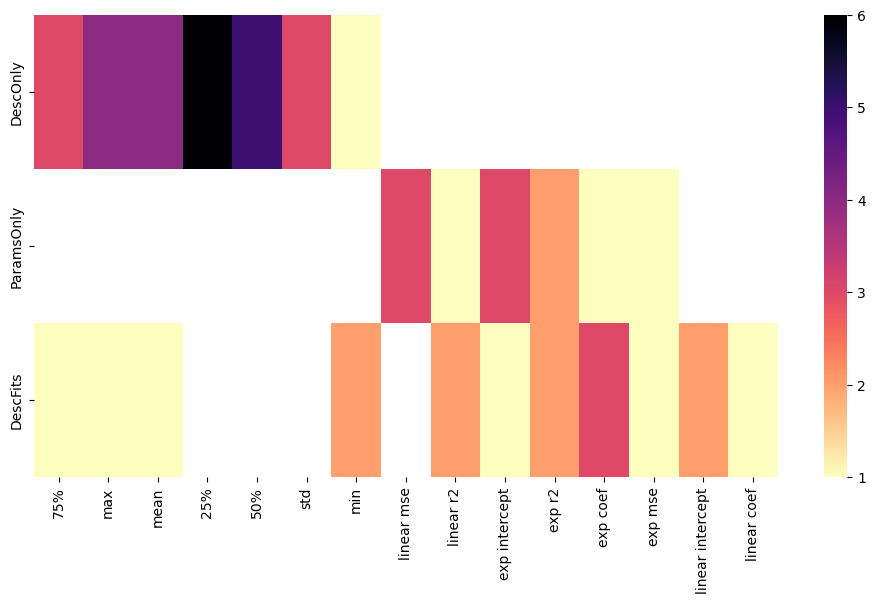

In [187]:
fig, ax = plt.subplots(figsize = (12,6))
sns.heatmap(count_orgData.T, ax=ax, cmap = cmap)
fig, ax2 = plt.subplots(figsize = (12,6))
sns.heatmap(count_transforms.iloc[2:].T.iloc[1:], ax=ax2, cmap = cmap)

In [188]:
dict_dataimport_all['DescFits'].iloc[:,1:]

,BUN_min,Beta-2-Microglobulin_75%,Immature Gran Auto_mean,Pct Neutrophil_min,Serum Electrophoresis Beta_max,BUN_linear_r2,Calcium_linear_r2,Chloride_linear_intercept,Platelet Count_linear_intercept,Troponin-T_linear_coef,BUN_exp_r2,MCV_exp_coef,Pct Immature Gran Auto_exp_mse,Platelet Count_exp_coef,Potassium_exp_r2,WBC_exp_coef,NT Pro BNP_exp_intercept
0,15,18.100,0.078182,46.5,0.6,0.226827,0.000005,101.611650,213.993209,0.000778,0.210679,0.000248,6.673658e-03,-0.002584,0.150139,-0.002440,6.245677
1,27,10.550,0.056154,61.7,1.0,0.553746,0.774640,107.548838,741.104478,-0.000291,0.563138,0.000110,2.152999e-02,-0.001449,0.255786,-0.000405,8.951901
2,13,18.250,0.077333,21.4,7.0,0.254559,0.032920,104.008222,140.783020,0.000042,0.277690,0.000085,1.493546e-01,0.000201,0.010828,-0.000059,5.995790
3,27,6.225,0.155000,80.8,0.7,0.594296,0.007176,96.340803,180.441925,-0.000112,0.630133,0.000250,2.187710e-02,0.001034,0.059980,-0.000219,8.267514
4,20,3.800,0.035714,38.9,0.9,0.396025,0.001207,85.762770,64.303085,0.000000,0.387801,0.000026,2.752140e-02,0.000468,0.104033,0.000404,9.097141
5,11,10.275,0.075926,62.0,1.0,0.500833,0.290253,99.884605,442.344547,-0.000041,0.571987,0.000060,3.328802e-02,-0.000209,0.017377,0.000500,8.451165
6,5,5.000,0.048298,45.8,1.0,0.024222,0.660202,99.504914,297.381473,0.000000,0.022725,-0.000021,5.672410e-02,-0.000324,0.078775,-0.000730,6.775088
7,13,2.825,0.195333,3.4,14.0,0.002943,0.000293,106.603200,332.455570,0.000000,0.001773,0.000189,4.568548e-01,-0.009229,0.000812,-0.003737,5.665584
8,9,2.575,0.031111,64.8,0.8,0.208944,0.002009,96.659978,268.513425,-0.000024,0.238951,0.000025,8.217030e-03,0.000060,0.004929,-0.000726,8.795142
9,47,9.250,0.054286,49.0,1.5,0.062488,0.008804,104.746172,226.779128,0.000000,0.055018,0.000053,1.420717e-02,-0.001063,0.004727,-0.000699,9.252729


## correlation plots by model

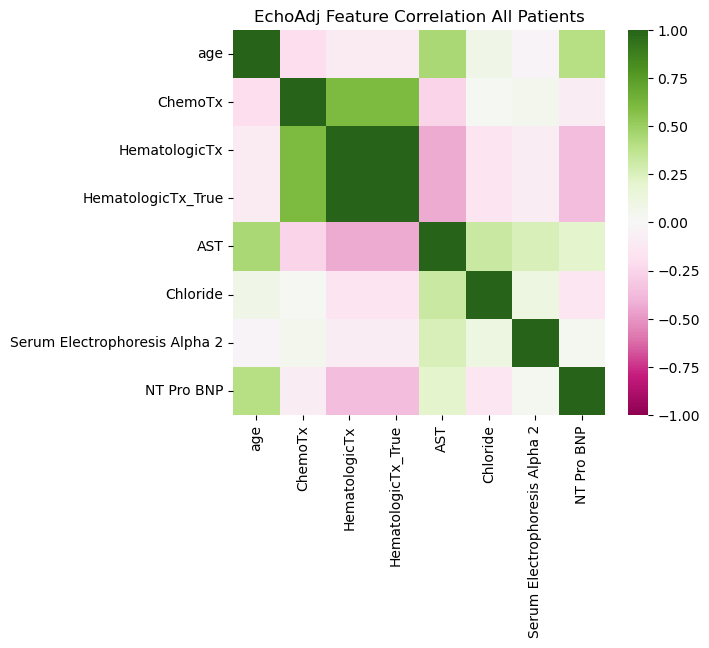

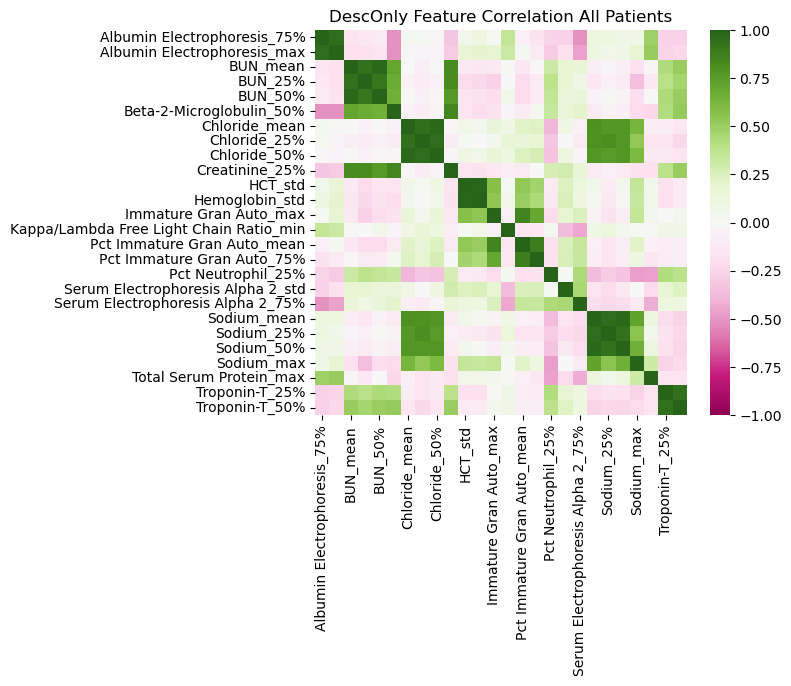

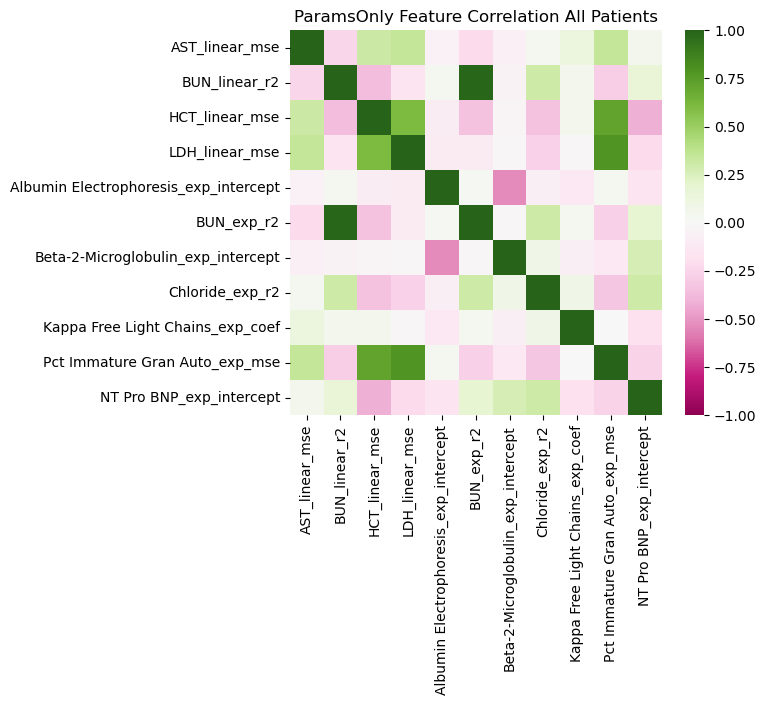

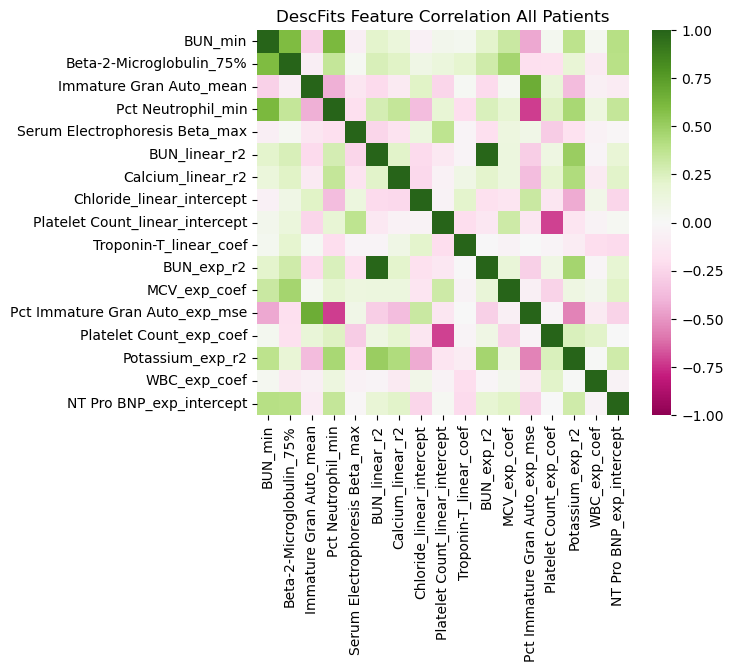

In [ ]:
# correlation map of only the selected features
for model in modelNames:
    fig, ax = plt.subplots(figsize= (6,5))
    feature_corr = dict_dataimport_all[model].iloc[:,1:].corr(method = 'spearman')
    sns.heatmap(feature_corr, cmap = "PiYG", vmin =-1, vmax = 1, center = 0, annot = False, ax= ax)
    plt.title(str(model)+ " Feature Correlation All Patients")


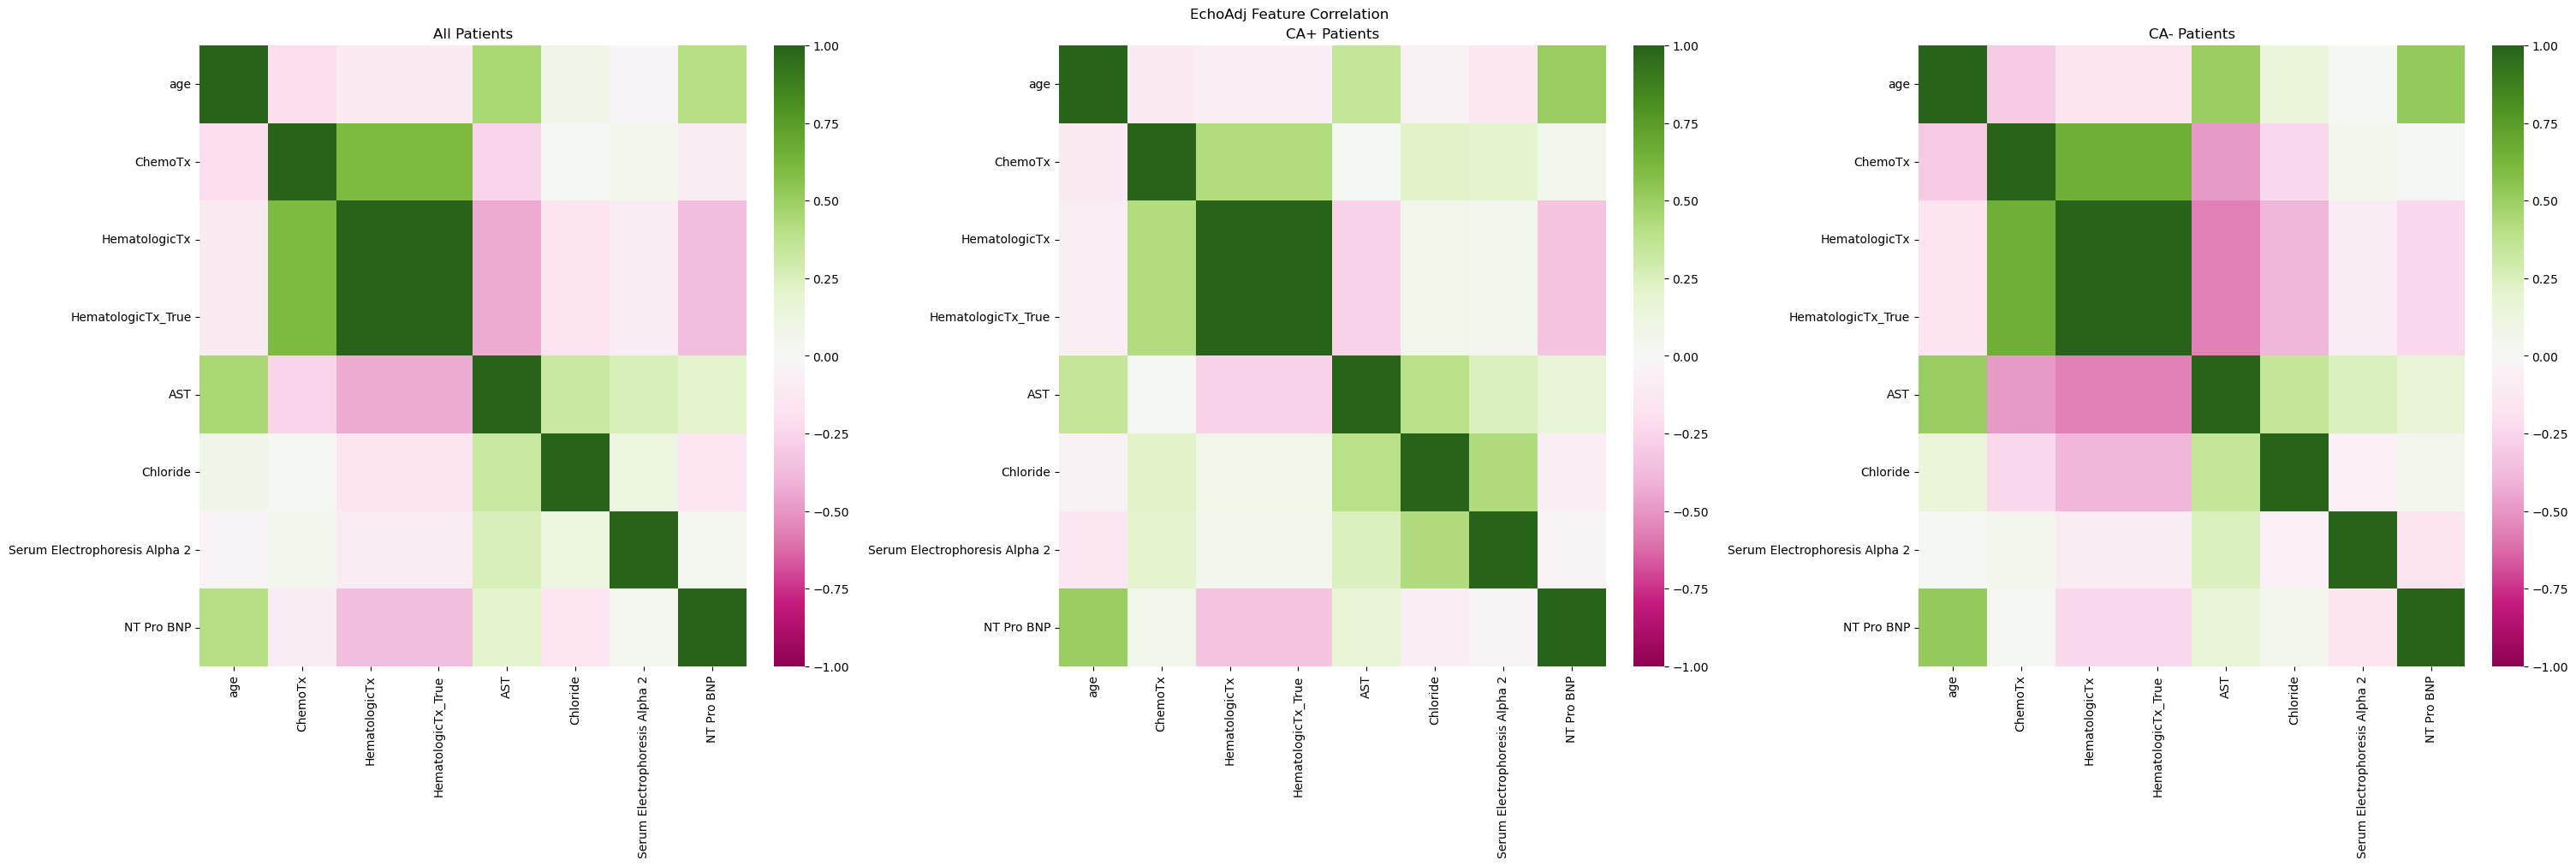

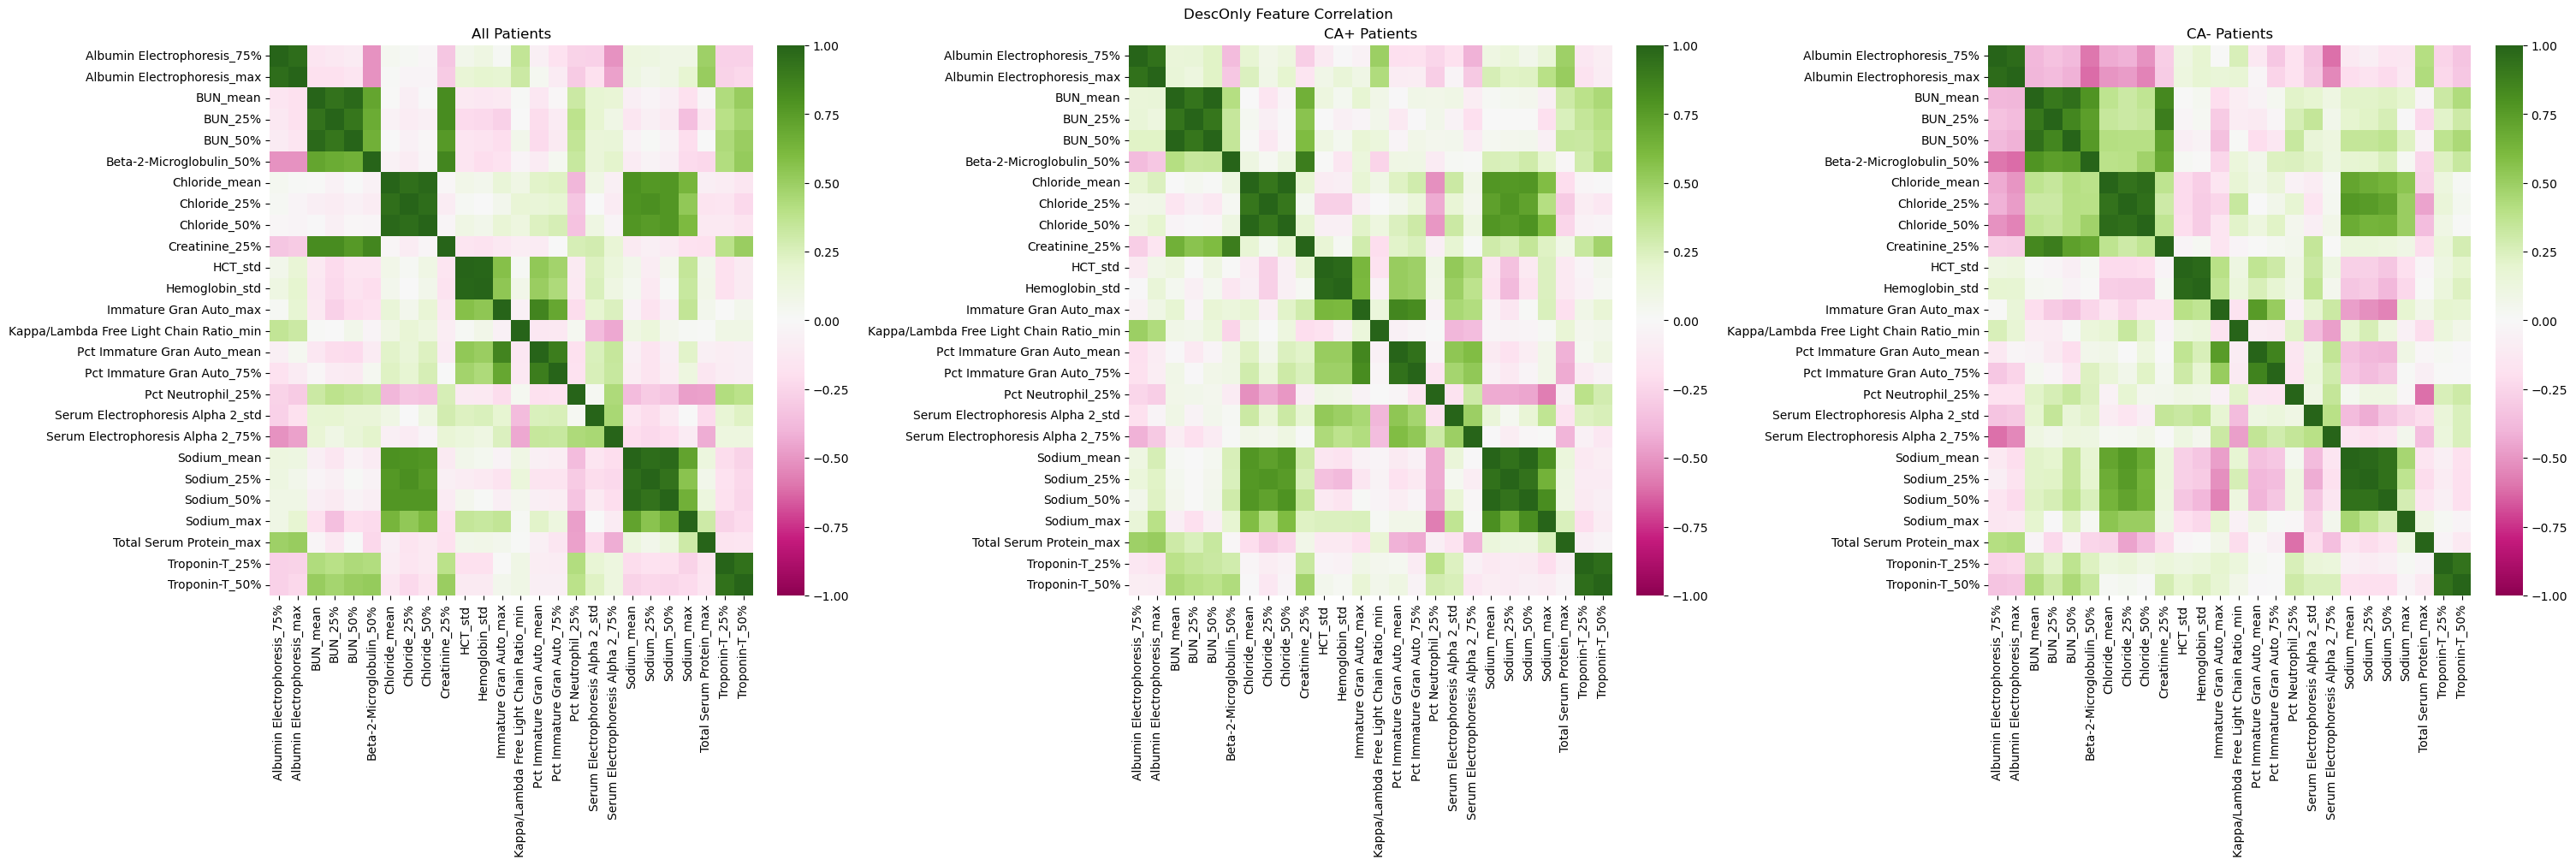

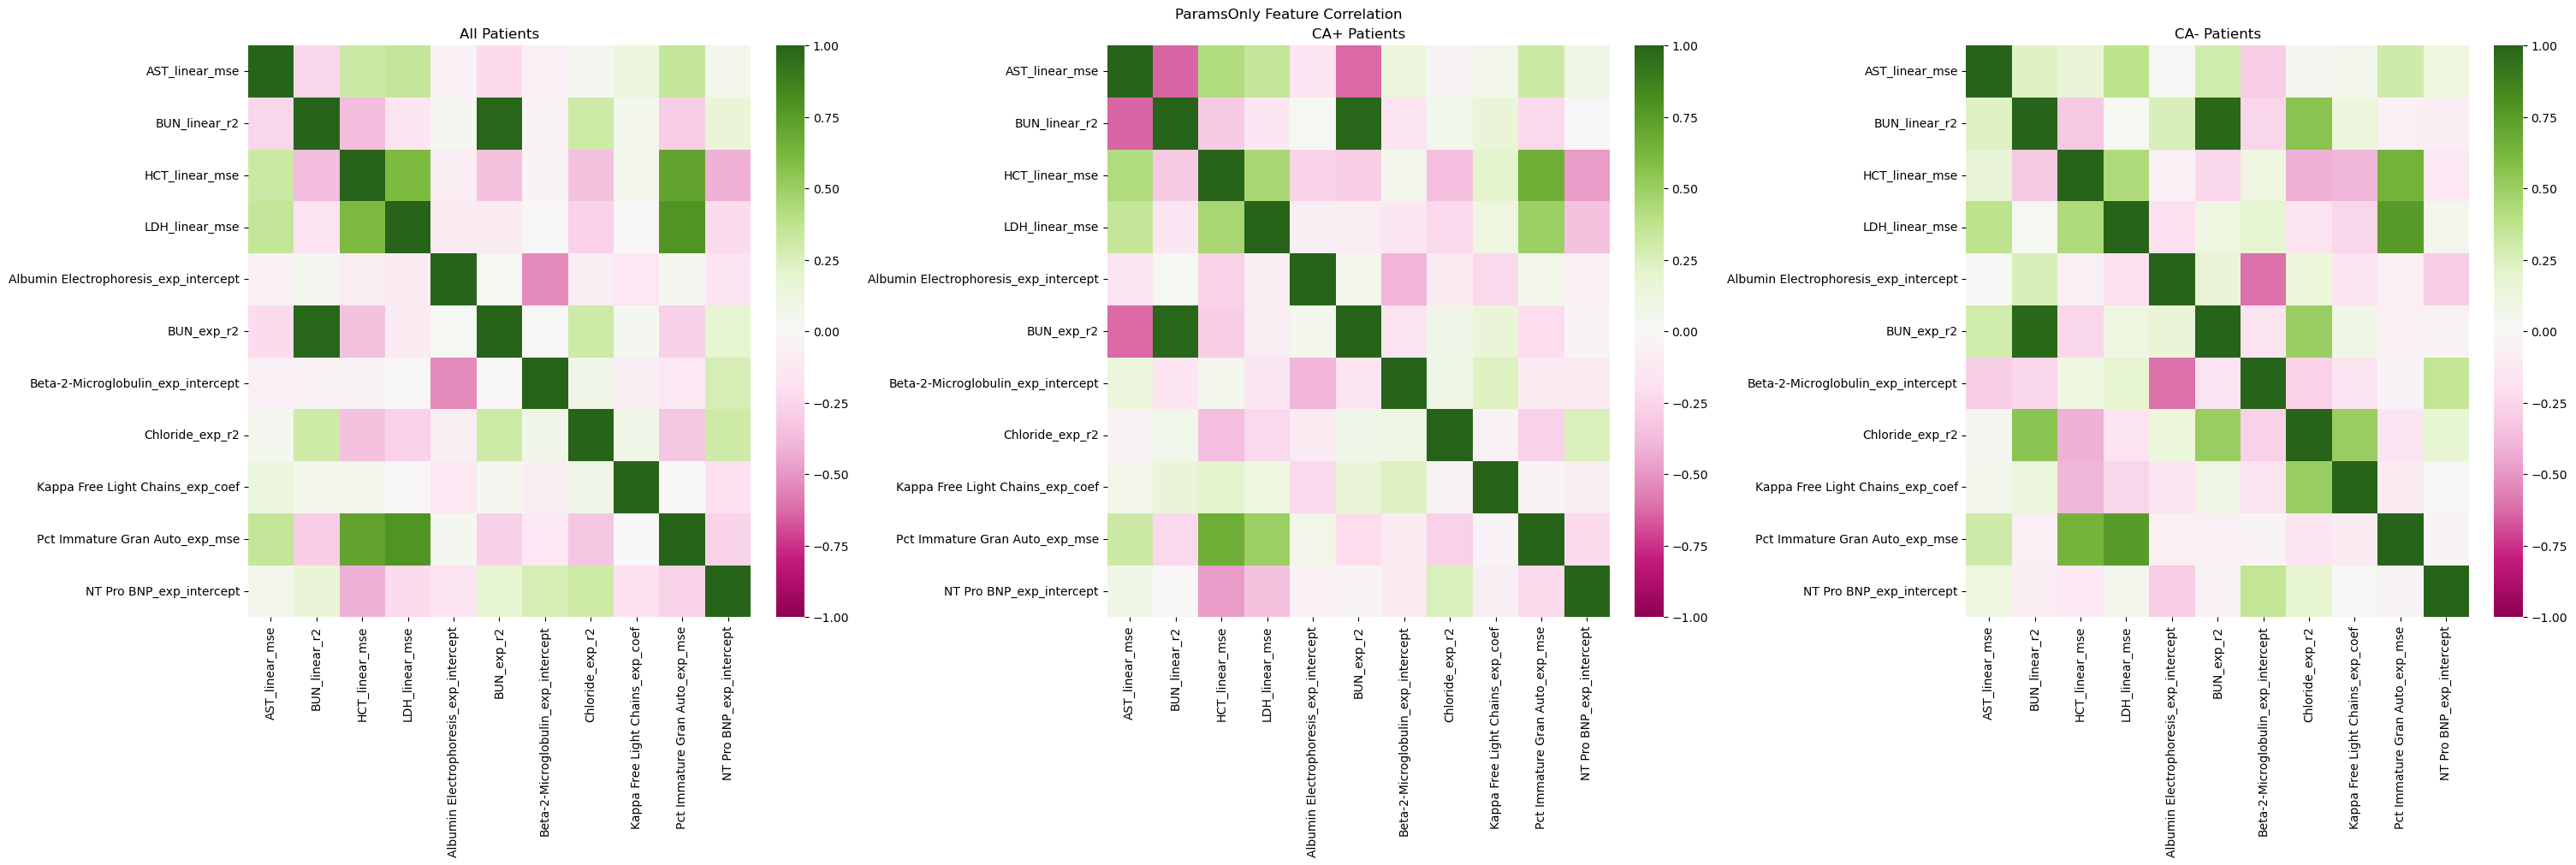

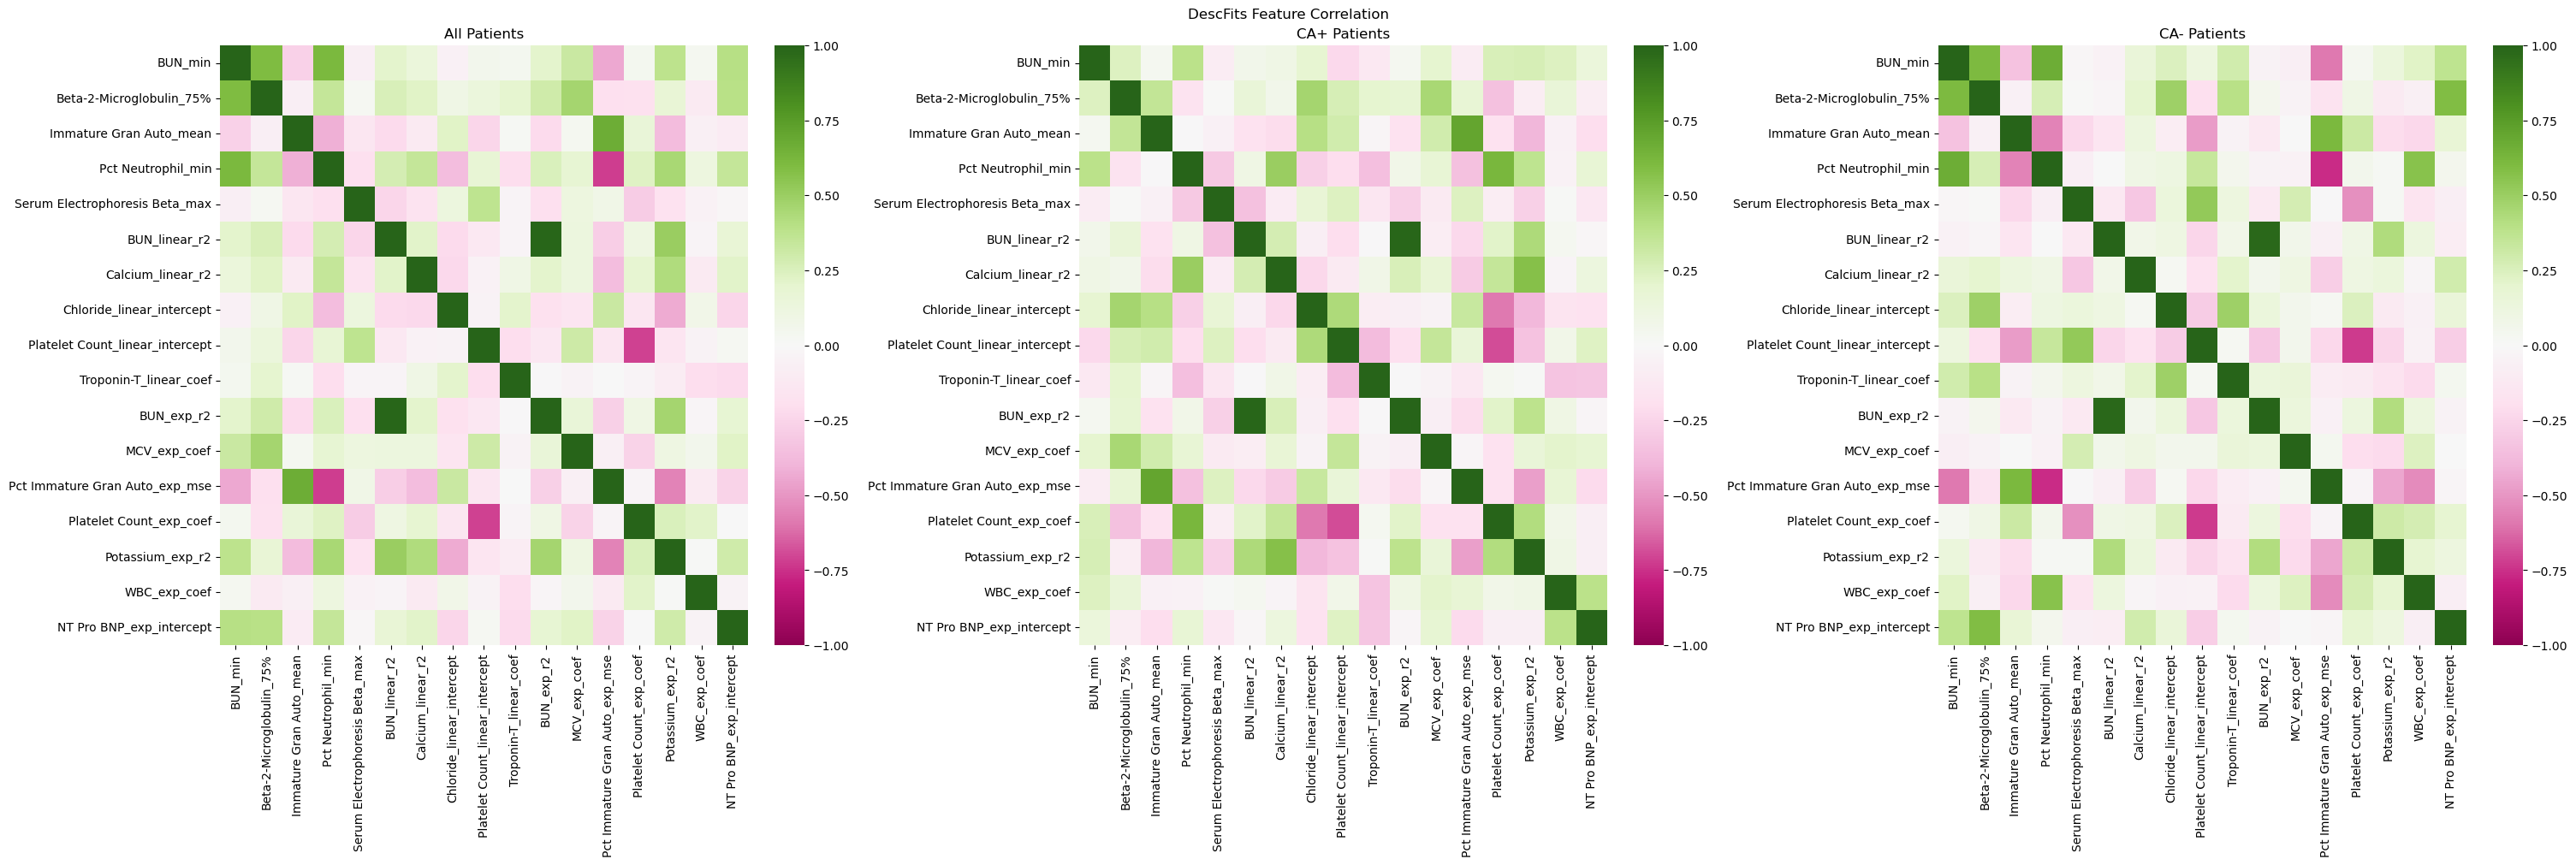

In [210]:
# correlation map of only the selected features
for model in modelNames:
    fig= plt.figure(figsize = (30,10), layout ='constrained')
    fig.suptitle(str(model)+ " Feature Correlation")
    ax1 = plt.subplot2grid((1, 3), (0,0))
    feature_corr = dict_dataimport_all[model].iloc[:,1:].corr(method = 'spearman')
    sns.heatmap(feature_corr, cmap = "PiYG", vmin =-1, vmax = 1, center = 0, annot = False, ax= ax1)
    ax1.set_title("All Patients")

    ax2 = plt.subplot2grid((1, 3), (0,1))
    feature_corr = dict_dataimport_positive[model].iloc[:,1:].corr(method = 'spearman')
    sns.heatmap(feature_corr, cmap = "PiYG", vmin =-1, vmax = 1, center = 0, annot = False, ax= ax2)
    ax2.set_title("CA+ Patients")

    ax3 = plt.subplot2grid((1, 3), (0,2))
    feature_corr = dict_dataimport_negative[model].iloc[:,1:].corr(method = 'spearman')
    sns.heatmap(feature_corr, cmap = "PiYG", vmin =-1, vmax = 1, center = 0, annot = False, ax= ax3)
    ax3.set_title("CA- Patients")

    



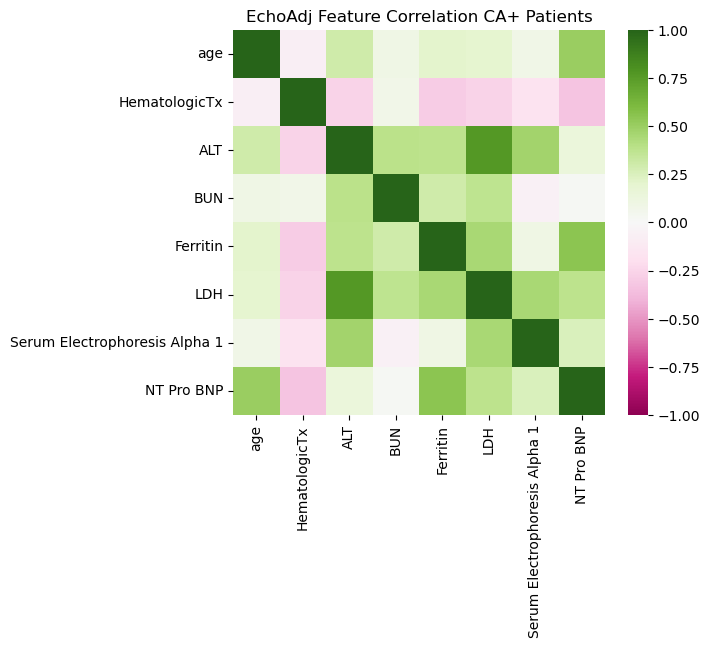

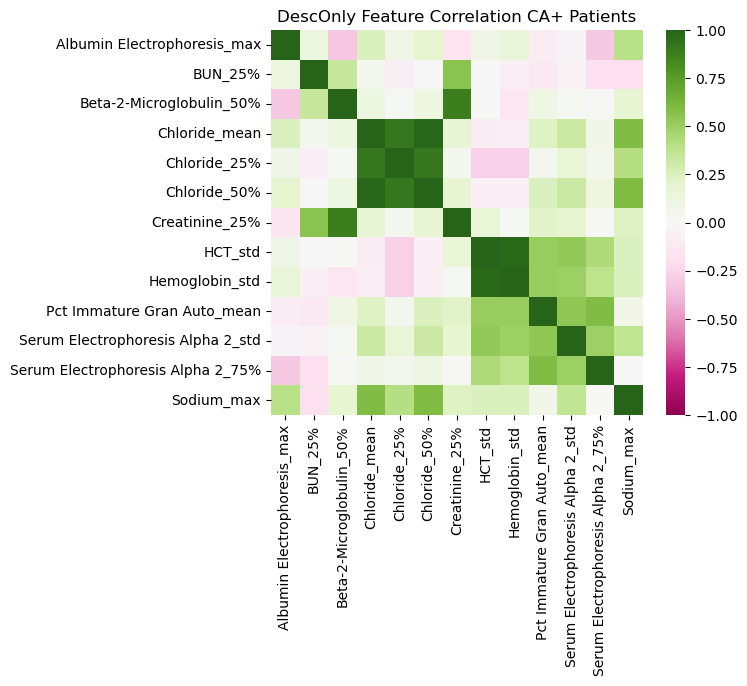

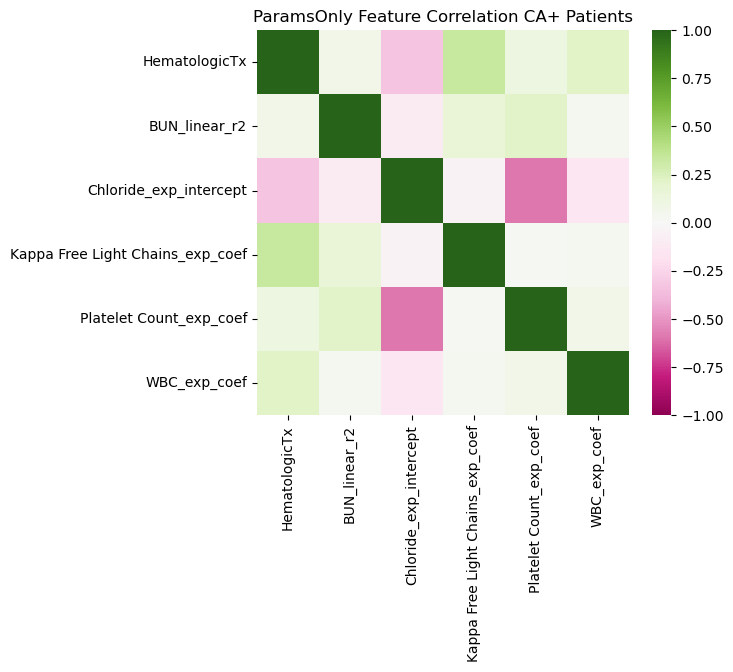

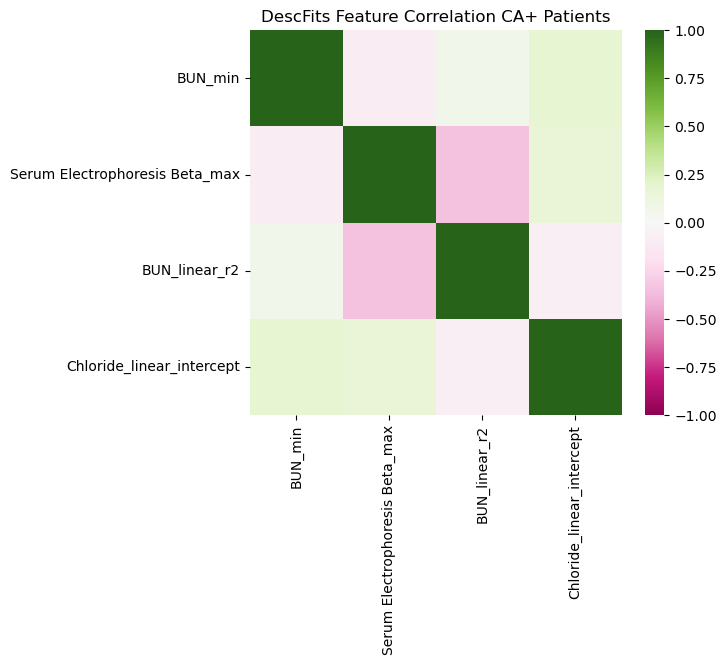

In [194]:
# correlation map of only the selected features
#CA+ patients only
for model in modelNames:
    fig, ax = plt.subplots(figsize= (6,5))
    feature_corr = dict_dataimport_positive[model].iloc[:,1:].corr(method = 'spearman')
    sns.heatmap(feature_corr, cmap = "PiYG", vmin =-1, vmax = 1, center = 0, annot = False, ax= ax)
    plt.title(str(model)+ " Feature Correlation CA+ Patients")

In [ ]:
# correlation map of only the selected features
#CA- patients only
for model in modelNames:
    fig, ax = plt.subplots(figsize= (6,5))
    feature_corr = dict_dataimport_negative[model].iloc[:,1:].corr(method = 'spearman')
    sns.heatmap(feature_corr, cmap = "PiYG", vmin =-1, vmax = 1, center = 0, annot = False, ax= ax)
    plt.title(str(model)+ " Feature Correlation CA- Patients")

# visualization second round feature selection

## frequency of features

<Axes: >

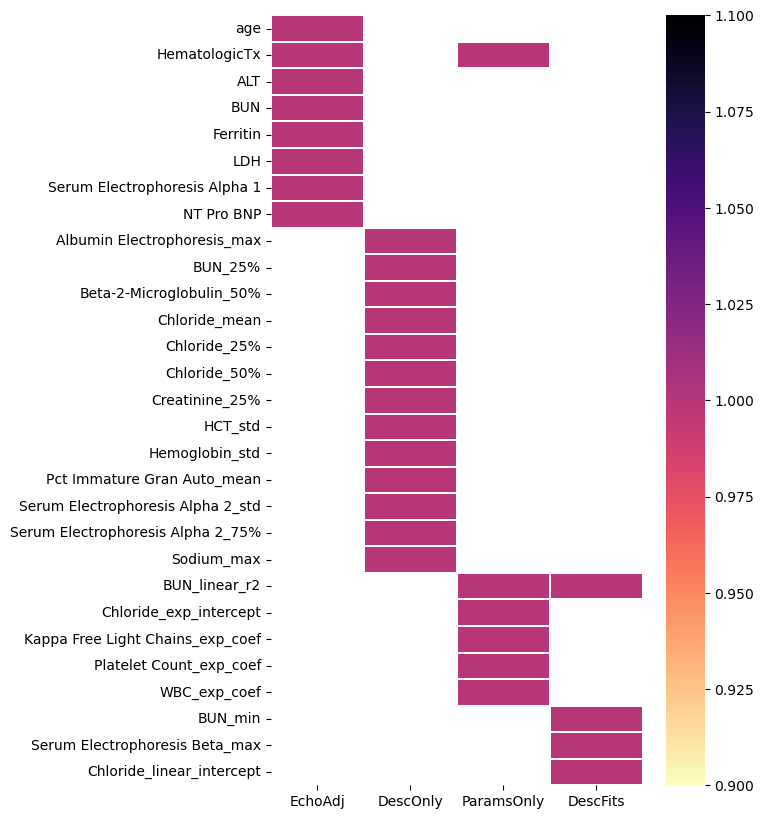

In [122]:
#plotting heatmap for feature frequency across models
fig, ax = plt.subplots(figsize = (6,10))
sns.heatmap(count_selectedFeats_second, cmap = cmap, ax = ax, linewidths = 0.1)

<Axes: >

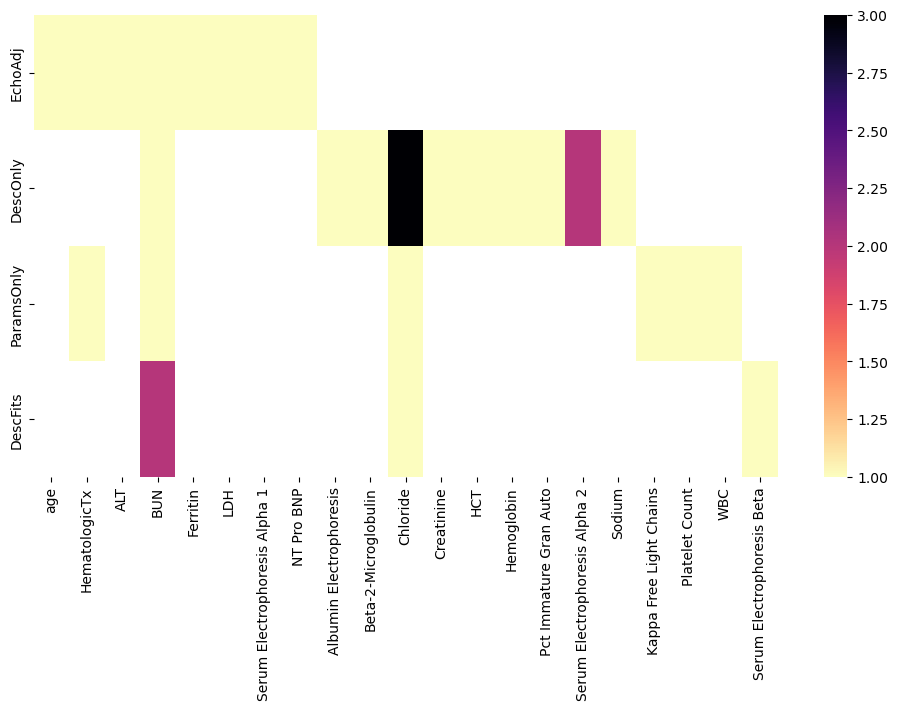

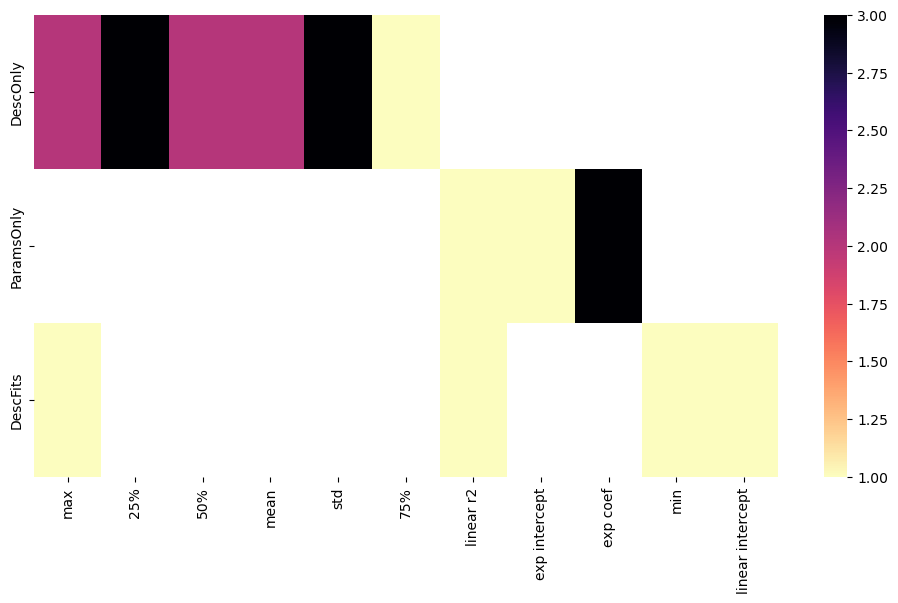

In [ ]:
fig, ax = plt.subplots(figsize = (12,6))
sns.heatmap(count_orgData_second.T, ax=ax, cmap = cmap)

fig, ax2 = plt.subplots(figsize = (12,6))
sns.heatmap(count_transforms_second.iloc[1:].T.iloc[1:], ax=ax2, cmap = cmap)

Text(0.5, 1.0, 'Frequency of Data Characteristic')

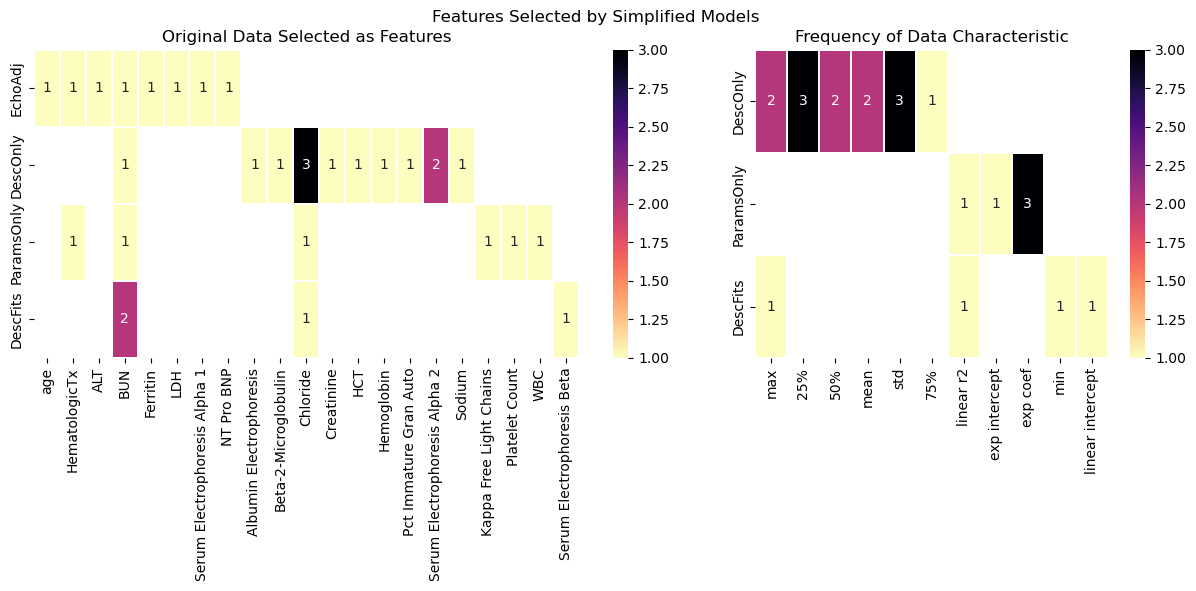

In [225]:
fig= plt.figure(figsize = (15,4))
fig.suptitle("Features Selected by Simplified Models")
ax1 = plt.subplot2grid((1, 5), (0,0), colspan = 3)
sns.heatmap(count_orgData_second.T, ax=ax1, cmap = cmap, linewidths=0.1, annot=True)
ax1.set_title("Original Data Selected as Features")
ax2 = plt.subplot2grid((1, 5), (0,3), colspan=2)
sns.heatmap(count_transforms_second.iloc[1:].T.iloc[1:], ax=ax2, cmap = cmap, linewidths=0.1, annot= True)
ax2.set_title("Frequency of Data Characteristic")

## correlation plots

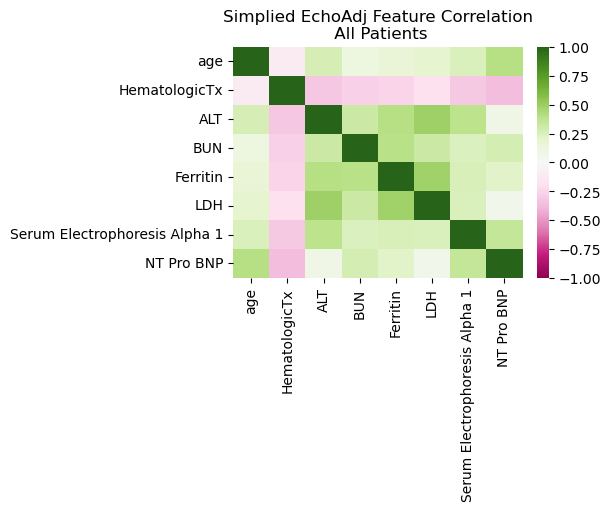

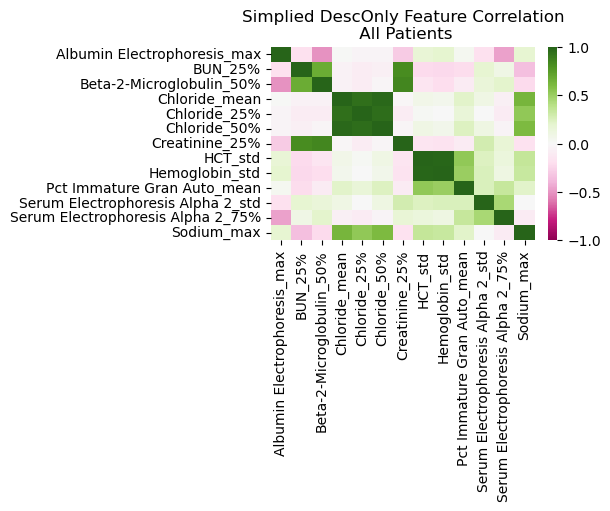

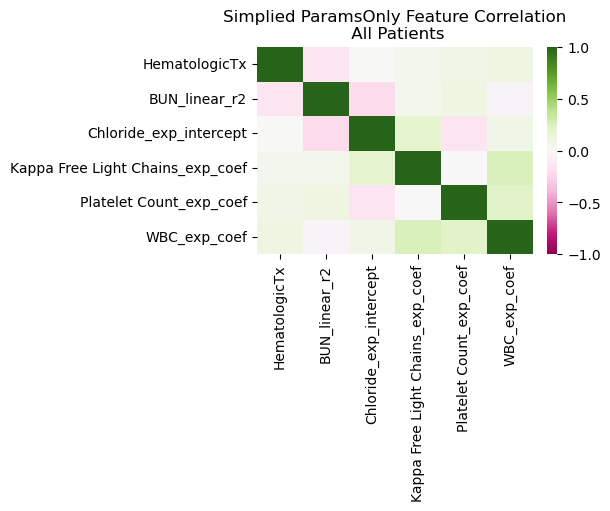

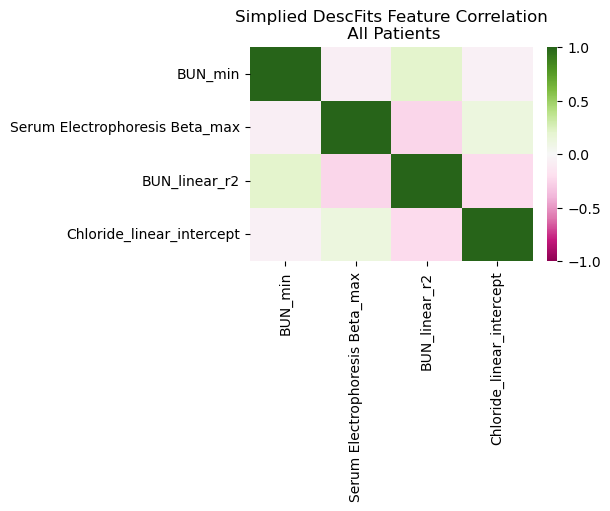

In [217]:
for model in modelNames:
    fig, ax1= plt.subplots(figsize = (6,5), layout ='constrained')
    ax1.set_title("Simplied "+ str(model) + " Feature Correlation"+ "\n All Patients")
    # ax1 = plt.subplot2grid((1, 3), (0,0))
    feature_corr = dict_dataimport_all_second[model].iloc[:,1:].corr(method = 'spearman')
    sns.heatmap(feature_corr, cmap = "PiYG", vmin =-1, vmax = 1, center = 0, annot = False, ax= ax1)
    # ax1.set_title("All Patients")

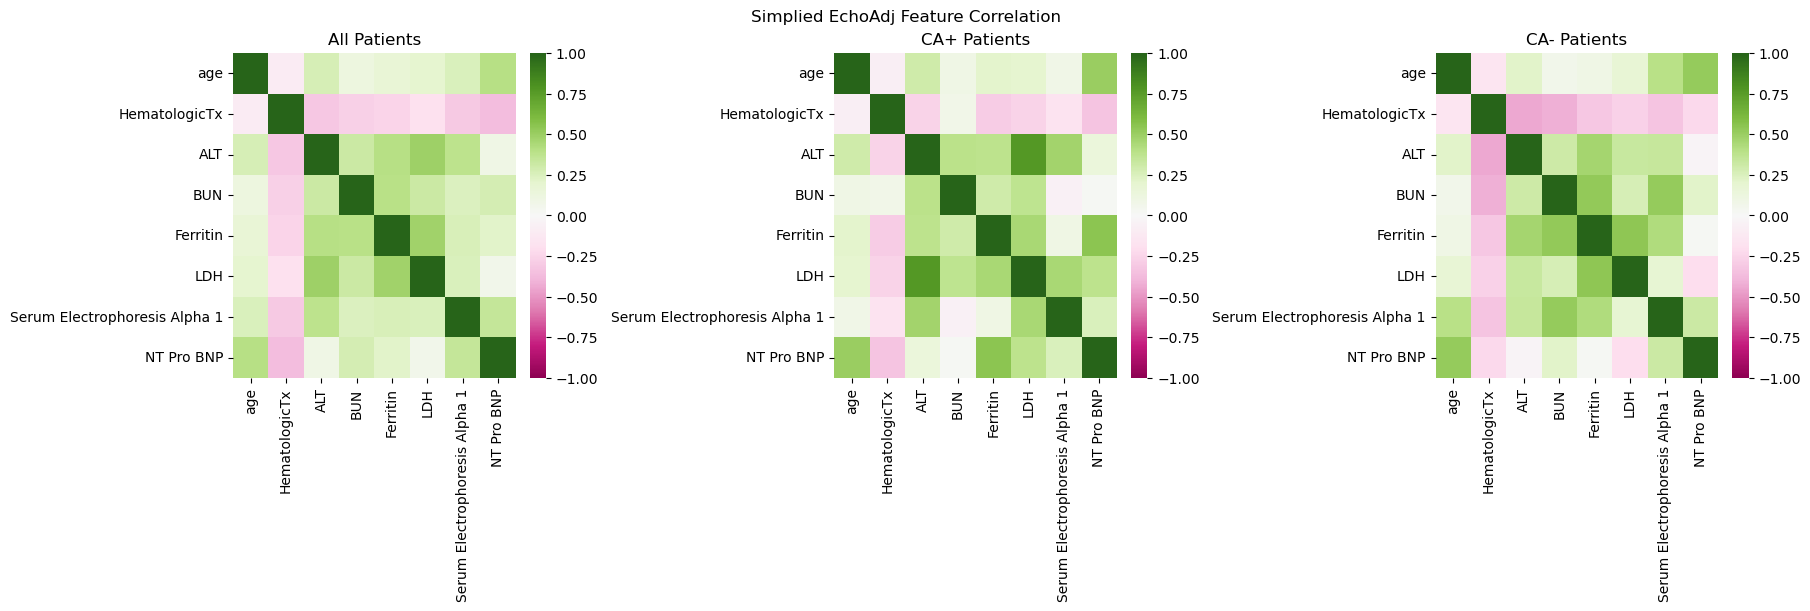

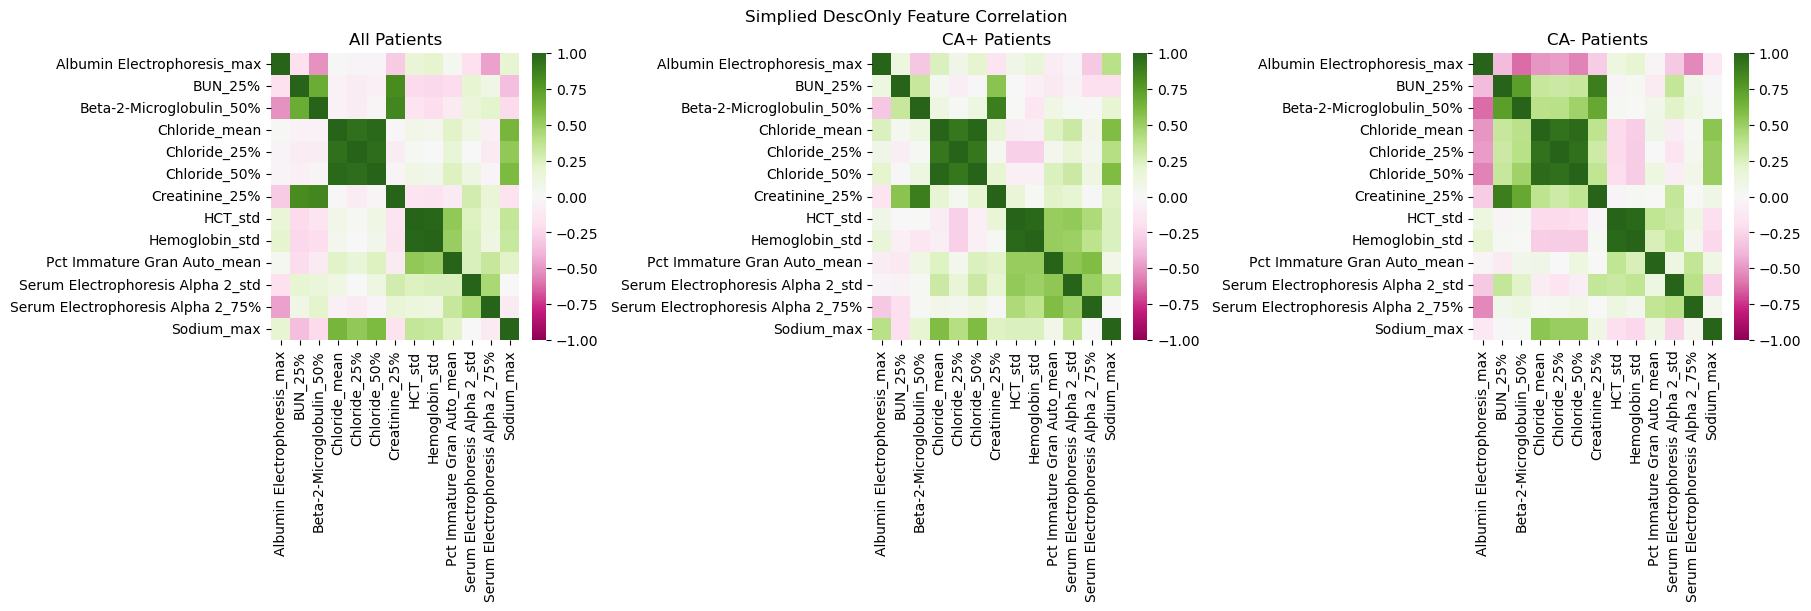

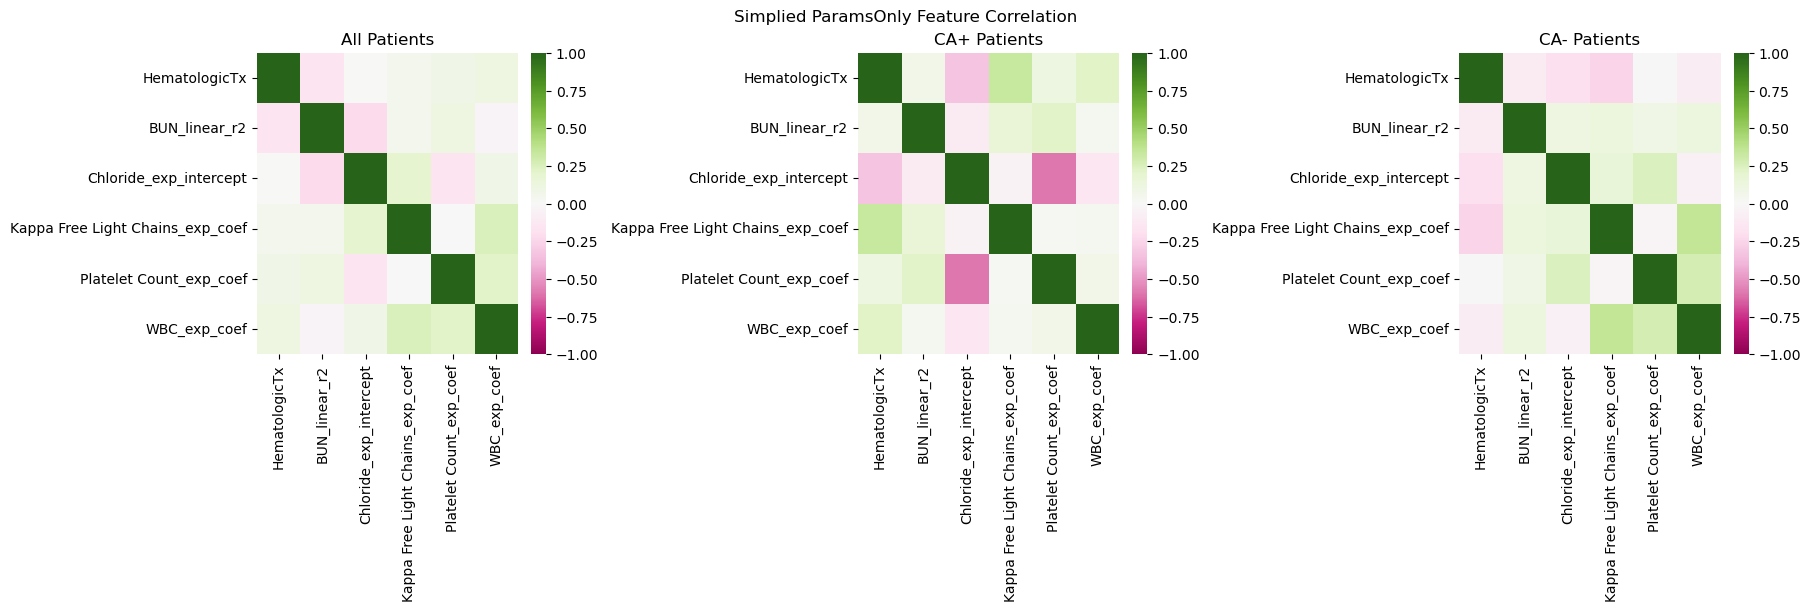

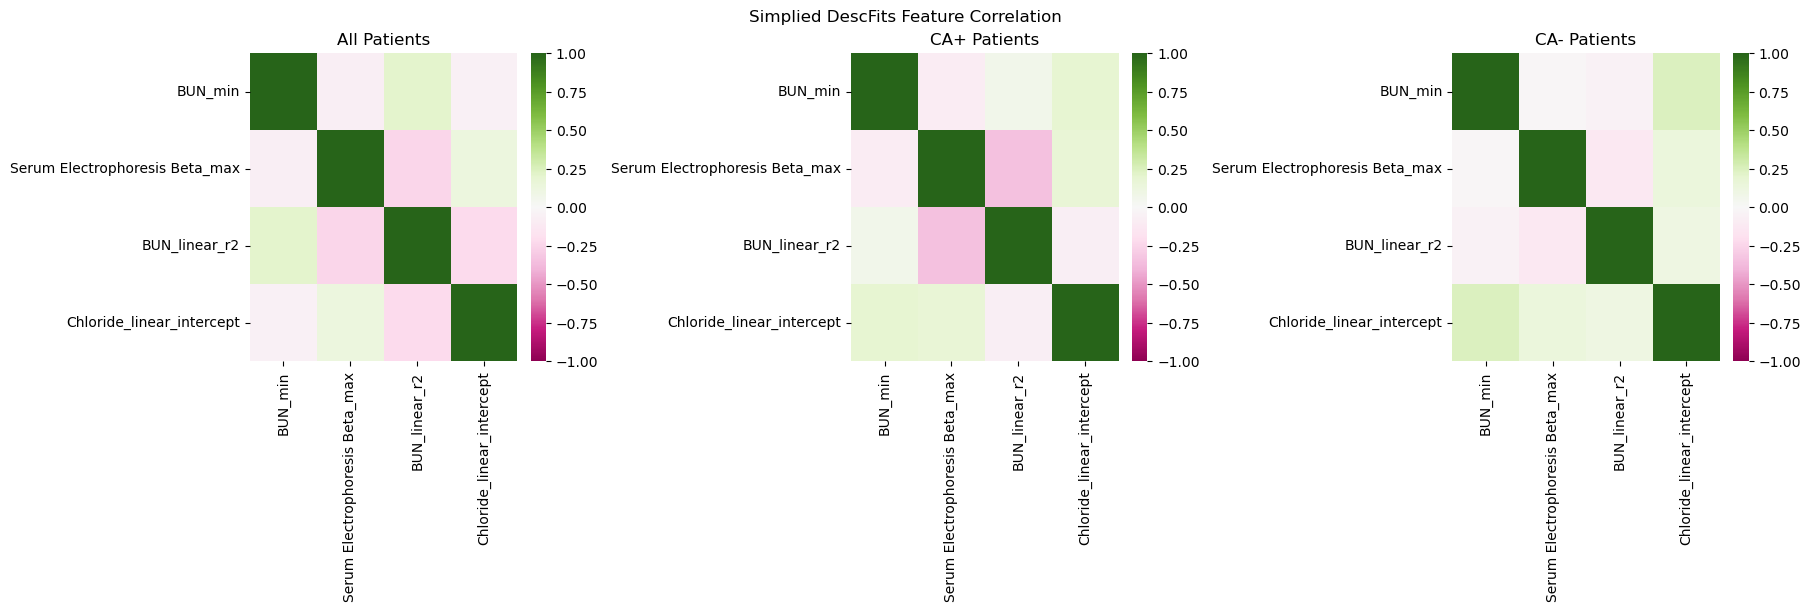

In [212]:
# correlation map of only the selected features
for model in modelNames:
    fig= plt.figure(figsize = (18,6), layout ='constrained')
    fig.suptitle("Simplied "+ str(model) + " Feature Correlation")
    ax1 = plt.subplot2grid((1, 3), (0,0))
    feature_corr = dict_dataimport_all_second[model].iloc[:,1:].corr(method = 'spearman')
    sns.heatmap(feature_corr, cmap = "PiYG", vmin =-1, vmax = 1, center = 0, annot = False, ax= ax1)
    ax1.set_title("All Patients")

    ax2 = plt.subplot2grid((1, 3), (0,1))
    feature_corr = dict_dataimport_positive_second[model].iloc[:,1:].corr(method = 'spearman')
    sns.heatmap(feature_corr, cmap = "PiYG", vmin =-1, vmax = 1, center = 0, annot = False, ax= ax2)
    ax2.set_title("CA+ Patients")

    ax3 = plt.subplot2grid((1, 3), (0,2))
    feature_corr = dict_dataimport_negative_second[model].iloc[:,1:].corr(method = 'spearman')
    sns.heatmap(feature_corr, cmap = "PiYG", vmin =-1, vmax = 1, center = 0, annot = False, ax= ax3)
    ax3.set_title("CA- Patients")

    

